<a href="https://colab.research.google.com/github/epicariello/zone30/blob/main/Zone30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Questo notebook è stato utilizzato per la realizzazione della tesi L'effetto dell'istituzione della zona 30 km/h sulla mortalità negli incidenti automobilistici**
  

Si carica un dataset ISTAT che contiene gli incidenti con morti e feriti di tutti i comuni d'Italia in serie storica

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

import pandas as pd
import numpy as np
import re

# File path
file_path = '/content/drive/MyDrive/TesiMagistrale/FontiUsate/Incidenti, morti e feriti - comuni.xlsx'

# Carica dati dalla riga 8 (salta 7 righe), NO header
df = pd.read_excel(file_path, skiprows=7, header=None)

# Crea nomi colonne: Comune + morti/feriti/incidenti per 2001-2024
anni = range(2001, 2025)
colonne = ['Comune']
for anno in anni:
    colonne.extend([f'{anno}_morti', f'{anno}_feriti', f'{anno}_incidenti'])

df.columns = colonne

# 🔧 PULIZIA ROBUSTA per risolvere l'errore '..'
def pulisci_valori(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip()
    # Rimuovi '..', ',', e non numeri
    if val_str == '..' or val_str == 'nan':
        return 0
    # Rimuovi virgole per numeri italiani
    val_str = val_str.replace(',', '')
    try:
        return int(float(val_str))
    except (ValueError, TypeError):
        return 0

# Applica pulizia a TUTTE le colonne numeriche
colonne_num = [col for col in df.columns if col != 'Comune']
for col in colonne_num:
    df[col] = df[col].apply(pulisci_valori)

# Pulisci 'Comune'
df['Comune'] = df['Comune'].astype(str).str.strip()
df = df[df['Comune'].str.len() > 0].reset_index(drop=True)

print(f"✅ DataFrame 'df' pronto! Shape: {df.shape}")
print("\nPrime righe:")
print(df[['Comune', '2001_morti', '2001_feriti', '2001_incidenti',
          '2024_morti', '2024_feriti', '2024_incidenti']].head())

print("\n📊 Pronto per analisi!")


✅ DataFrame 'df' pronto! Shape: (8578, 73)

Prime righe:
            Comune  2001_morti  2001_feriti  2001_incidenti  2024_morti  \
0            Agliè           0           10               5           0   
1          Airasca           0           48              25           0   
2     Ala di Stura           0            0               0           0   
3  Albiano d'Ivrea           1            6               5           0   
4  Alice Superiore           4            3               3           0   

   2024_feriti  2024_incidenti  
0            5               2  
1            9               5  
2            2               1  
3            9               4  
4            0               0  

📊 Pronto per analisi!


E' necessario un preprocessing poiché alcuni comuni hanno cambiato provincia nel corso del tempo (in particolare è accaduto a Olbia) per questo i dati si trovano in righe diverse, pur essendo, nel complesso, completo

In [2]:
# ============================================================
# PREPROCESSING - Gestione comuni duplicati
# ============================================================

# --- IDENTIFICAZIONE ---
dupes_mask = df['Comune'].duplicated(keep=False)
dupe_names = df.loc[dupes_mask, 'Comune'].unique()
print(f"Comuni con nome duplicato: {len(dupe_names)}")

colonne_num = [col for col in df.columns if col != 'Comune']

# --- CLASSIFICAZIONE ---
# Complementari: dove una riga ha il dato, l'altra ha 0 (mai sovrapposizione)
#                → merge sicuro per somma (es. Olbia cambio provincia)
# Conflitto:     stessa colonna ha valori > 0 su entrambe le righe
#                → comuni omonimi in province diverse, si lasciano separati

complementary = []
conflict = []

for nome in dupe_names:
    rows = df[df['Comune'] == nome]
    has_conflict = False
    for col in colonne_num:
        vals = rows[col].tolist()
        non_zero = [v for v in vals if v != 0]
        if len(non_zero) > 1:
            has_conflict = True
            break
    if has_conflict:
        conflict.append(nome)
    else:
        complementary.append(nome)

print(f"  → Merge per somma (cambio provincia, es. Olbia): {len(complementary)}")
print(f"  → Lasciati separati (comuni omonimi):            {len(conflict)}")
print(f"  → Comuni omonimi non toccati: {conflict}")

# --- MERGE SOLO PER I COMPLEMENTARI ---
idx_to_drop = set()
merged_rows = []

for nome in complementary:
    rows = df[df['Comune'] == nome]
    idx_to_drop.update(rows.index.tolist())
    merged = {'Comune': nome}
    for col in colonne_num:
        merged[col] = rows[col].sum()
    merged_rows.append(merged)

df_merged = pd.DataFrame(merged_rows)

# --- ASSEMBLAGGIO ---
# I comuni in conflitto rimangono intatti nel df originale
df = df.drop(index=list(idx_to_drop))
df = pd.concat([df, df_merged], ignore_index=True)
df = df.sort_values('Comune').reset_index(drop=True)

print(f"\nDataset pulito: {len(df)} righe, {df['Comune'].nunique()} comuni unici")
print(f"(Nota: {len(conflict)} comuni omonimi mantengono righe doppie)")

# --- VERIFICA Bologna e Olbia ---
for nome in ['Bologna', 'Olbia']:
    row = df[df['Comune'] == nome].iloc[0]
    morti = [str(int(row[f'{a}_morti'])) for a in range(2001, 2025)]
    print(f"\n{nome} - Morti 2001→2024:")
    print(', '.join(morti))

print("\n✅ Preprocessing completato! df aggiornato e pronto per l'analisi.")


Comuni con nome duplicato: 294
  → Merge per somma (cambio provincia, es. Olbia): 288
  → Lasciati separati (comuni omonimi):            6
  → Comuni omonimi non toccati: ['Samone', 'Livo', 'Peglio', 'Castro', 'Valverde', 'San Teodoro']

Dataset pulito: 8223 righe, 8215 comuni unici
(Nota: 6 comuni omonimi mantengono righe doppie)

Bologna - Morti 2001→2024:
32, 39, 46, 35, 28, 36, 28, 20, 26, 28, 20, 22, 7, 18, 25, 16, 15, 25, 18, 14, 12, 23, 21, 11

Olbia - Morti 2001→2024:
6, 10, 15, 9, 11, 4, 8, 1, 6, 7, 5, 3, 10, 2, 4, 3, 3, 6, 2, 3, 3, 3, 4, 6

✅ Preprocessing completato! df aggiornato e pronto per l'analisi.


Si carica un dataset dei Comuni dell'Emilia Romagna

In [3]:
import pandas as pd
import numpy as np

# Carica Comuni Emilia-Romagna
df_comuni_emilia_romagna = pd.read_excel('/content/drive/MyDrive/TesiMagistrale/FontiUsate/Comuni_Emilia_Romagna.xlsx')

print("✅ df_comuni_emilia_romagna pronto!")
print(f"Shape: {df_comuni_emilia_romagna.shape}")
print("\nColonne:")
print(df_comuni_emilia_romagna.columns.tolist())
print("\nPrime righe:")
print(df_comuni_emilia_romagna.head())

print("\n📊 Riepilogo:")
print(df_comuni_emilia_romagna['Provincia'].value_counts())
print(f"\nTotale comuni: {len(df_comuni_emilia_romagna)}")


✅ df_comuni_emilia_romagna pronto!
Shape: (330, 4)

Colonne:
['Numero', 'Comune', 'Provincia', 'Popolazione (Censimento 2011)']

Prime righe:
   Numero     Comune      Provincia  Popolazione (Censimento 2011)
0       1   Agazzano       Piacenza                           2070
1       2   Albareto          Parma                           2165
2       3    Albinea  Reggio Emilia                           8755
3       4  Alfonsine        Ravenna                          12245
4       5     Alseno       Piacenza                           4823

📊 Riepilogo:
Provincia
Bologna          55
Modena           47
Piacenza         46
Parma            44
Reggio Emilia    42
Forlì-Cesena     30
Rimini           27
Ferrara          21
Ravenna          18
Name: count, dtype: int64

Totale comuni: 330


Si verifica che tutti i comuni dell'Emilia Romagna siano presenti nel dataset iniziale

In [4]:
# Comuni presenti in df_comuni_emilia_romagna ma ASSENTI in df (incidenti)
comuni_emilia_non_incidenti = set(df_comuni_emilia_romagna['Comune'].str.lower()) - set(df['Comune'].str.lower())

print("🔍 **COMUNI EMILIA-ROMAGNA ASSENTI negli incidenti:**")
print(f"Totale: {len(comuni_emilia_non_incidenti)}")
if len(comuni_emilia_non_incidenti) > 0:
    print(list(comuni_emilia_non_incidenti)[:20])  # Primi 20
    if len(comuni_emilia_non_incidenti) > 20:
        print("... e altri", len(comuni_emilia_non_incidenti)-20)
else:
    print("✅ Tutti i comuni Emilia-Romagna sono presenti!")

print("\n📊 Riepilogo:")
print(f"Comuni Emilia-Romagna totali: {len(df_comuni_emilia_romagna)}")
print(f"Comuni con incidenti: {len(set(df['Comune'].str.lower()) & set(df_comuni_emilia_romagna['Comune'].str.lower()))}")
print(f"Copertura: {100*(1-len(comuni_emilia_non_incidenti)/len(df_comuni_emilia_romagna)):.1f}%")


🔍 **COMUNI EMILIA-ROMAGNA ASSENTI negli incidenti:**
Totale: 0
✅ Tutti i comuni Emilia-Romagna sono presenti!

📊 Riepilogo:
Comuni Emilia-Romagna totali: 330
Comuni con incidenti: 330
Copertura: 100.0%


Si carica un dataset contenente tutti i comuni della Sardegna

In [5]:
import pandas as pd
import numpy as np

# Carica Comuni Sardegna
df_comuni_sardegna = pd.read_excel('/content/drive/MyDrive/TesiMagistrale/FontiUsate/Comuni_Sardegna.xlsx')

print("✅ df_comuni_sardegna pronto!")
print(f"Shape: {df_comuni_sardegna.shape}")
print("\nColonne:")
print(df_comuni_sardegna.columns.tolist())
print("\nPrime righe:")
print(df_comuni_sardegna.head())

print("\n📊 Riepilogo:")
print(df_comuni_sardegna['Provincia'].value_counts())
print(f"\nTotale comuni: {len(df_comuni_sardegna)}")


✅ df_comuni_sardegna pronto!
Shape: (377, 5)

Colonne:
['Comune', 'Provincia', 'Popolazione (2021)', 'Altitudine (m)', 'Superficie (km²)']

Prime righe:
          Comune                  Provincia  Popolazione (2021)  \
0      Abbasanta                   Oristano                2579   
1         Aggius  Gallura Nord-Est Sardegna                1409   
2       Aglientu  Gallura Nord-Est Sardegna                1154   
3   Aidomaggiore                   Oristano                 398   
4  Alà dei Sardi  Gallura Nord-Est Sardegna                1764   

   Altitudine (m)  Superficie (km²)  
0             315             39.85  
1             514             86.31  
2             420            148.19  
3             250             41.21  
4             663            197.99  

📊 Riepilogo:
Provincia
Oristano                     87
Cagliari                     70
Sassari                      66
Nuoro                        53
Medio Campidano              28
Gallura Nord-Est Sardegna    26


Si verifica che tutti i Comuni della Sardegna siano nel dataset degli incidenti

In [6]:
# Verifica comuni SARDAGNA nel df incidenti
comuni_sardegna = set(df_comuni_sardegna['Comune'].str.lower())
comuni_incidenti = set(df['Comune'].str.lower())

comuni_sard_non_incidenti = comuni_sardegna - comuni_incidenti

print("🔍 **COMUNI SARDAGNA ASSENTI negli incidenti:**")
print(f"Totale: {len(comuni_sard_non_incidenti)}")
if len(comuni_sard_non_incidenti) > 0:
    print("\nPrimi 20:")
    for i, comune in enumerate(sorted(comuni_sard_non_incidenti)[:20]):
        print(f"  {i+1}. {comune.title()}")
    if len(comuni_sard_non_incidenti) > 20:
        print(f"\n... e altri {len(comuni_sard_non_incidenti)-20}")
else:
    print("✅ Tutti i comuni Sardegna SONO presenti!")

print(f"\n📊 Copertura:")
print(f"Comuni Sardegna totali: {len(df_comuni_sardegna):,}")
print(f"Comuni con incidenti: {len(comuni_sardegna & comuni_incidenti):,}")
print(f"Copertura: {100*(len(comuni_sardegna & comuni_incidenti)/len(df_comuni_sardegna)):.1f}%")


🔍 **COMUNI SARDAGNA ASSENTI negli incidenti:**
Totale: 0
✅ Tutti i comuni Sardegna SONO presenti!

📊 Copertura:
Comuni Sardegna totali: 377
Comuni con incidenti: 377
Copertura: 100.0%


In [7]:

import pandas as pd

# Carica il CSV della popolazione per comune per anno
df_pop = pd.read_csv(
    '/content/drive/MyDrive/TesiMagistrale/FontiUsate/popolazione_comuni_per_anno.csv',
    sep=';',
    decimal=',',
    encoding='latin-1'
)

# Rinomina per chiarezza
df_pop = df_pop.rename(columns={'codice': 'Codice', 'comune': 'Comune'})

print("✅ df_pop pronto!")
print(f"Shape: {df_pop.shape}")
print("\nColonne:")
print(df_pop.columns.tolist())
print("\nPrime righe:")
print(df_pop.head())

# -------------------------------------------------------
# Verifica: tutti i comuni di df sono presenti in df_pop?
# -------------------------------------------------------
comuni_df = set(df['Comune'].str.strip().str.lower())
comuni_pop = set(df_pop['Comune'].str.strip().str.lower())

assenti_in_pop = comuni_df - comuni_pop

print("\n🔍 Comuni presenti in df (incidenti) ma ASSENTI in df_pop (popolazione):")
print(f"Totale: {len(assenti_in_pop)}")
if assenti_in_pop:
    for c in sorted(assenti_in_pop):
        print(f"  - {c.title()}")
else:
    print("✅ Tutti i comuni di df sono presenti in df_pop!")

print(f"\n📊 Riepilogo copertura:")
print(f"Comuni in df (incidenti):   {len(comuni_df):,}")
print(f"Comuni in df_pop:            {len(comuni_pop):,}")
print(f"Comuni coperti:              {len(comuni_df & comuni_pop):,}")
print(f"Copertura: {100 * len(comuni_df & comuni_pop) / len(comuni_df):.1f}%")


✅ df_pop pronto!
Shape: (7991, 26)

Colonne:
['Codice', 'Comune', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

Prime righe:
   Codice           Comune    2002    2003    2004    2005    2006    2007  \
0    1001            Agliè  2557.0  2538.0  2588.0  2679.0  2674.0  2662.0   
1    1002          Airasca  3543.0  3544.0  3605.0  3648.0  3642.0  3666.0   
2    1003     Ala di Stura   480.0   468.0   461.0   458.0   458.0   467.0   
3    1004  Albiano d'Ivrea  1687.0  1673.0  1702.0  1696.0  1687.0  1661.0   
4    1006           Almese  5648.0  5679.0  5805.0  5863.0  6134.0  6157.0   

     2008    2009  ...    2016    2017    2018    2019    2020    2021  \
0  2658.0  2638.0  ...  2644.0  2661.0  2658.0  2634.0  2621.0  2545.0   
1  3775.0  3794.0  ...  3761.0  3726.0  3671.0  3613.0  3598.0  3633.0   
2   480.0   477.0  ...   464.0   460.

In [8]:
import pandas as pd
import numpy as np

# -------------------------------------------------------
# Costruzione dataset definitivo
# -------------------------------------------------------

# Chiave di join case-insensitive (colonna temporanea)
df_tmp = df.copy()
df_tmp['_key'] = df_tmp['Comune'].str.strip().str.lower()

df_pop_tmp = df_pop.copy()
df_pop_tmp['_key'] = df_pop_tmp['Comune'].str.strip().str.lower()

# Inner join → solo comuni presenti in entrambi
df_final = df_tmp.merge(df_pop_tmp, on='_key', suffixes=('', '_pop'))

# Rimuovi colonne ausiliarie
df_final = df_final.drop(columns=['_key', 'Comune_pop'])

# -------------------------------------------------------
# Calcolo tassi per gli anni sovrapposti: 2002–2024
# (df_pop copre 2002-2025, df copre 2001-2024)
# -------------------------------------------------------
anni_comuni = range(2002, 2025)

for anno in anni_comuni:
    pop = df_final[str(anno)].replace(0, np.nan)
    df_final[f'{anno}_tasso_mortalita']  = (df_final[f'{anno}_morti']  / pop * 1000).round(4)
    df_final[f'{anno}_tasso_ferimento']  = (df_final[f'{anno}_feriti'] / pop * 1000).round(4)

# Rimuovi le colonne grezze di popolazione (2002-2025)
pop_year_cols = [str(a) for a in range(2002, 2026) if str(a) in df_final.columns]
df_final = df_final.drop(columns=pop_year_cols)

# Rimuovi anno 2001 (no dati popolazione → niente tassi) e 2025 (no dati incidenti)
cols_2001 = [c for c in df_final.columns if c.startswith('2001_')]
cols_2025 = [c for c in df_final.columns if c.startswith('2025_') or c == '2025']
df_final = df_final.drop(columns=cols_2001 + cols_2025, errors='ignore')

# Rimuovi Codice
df_final = df_final.drop(columns=['Codice'], errors='ignore')

df_final = df_final.reset_index(drop=True)

print("✅ df_final pronto!")
print(f"Shape: {df_final.shape}")
print(f"Comuni: {len(df_final):,}")
print(f"Anni coperti: 2002–2024")

print("\nColonne (prime e ultime):")
cols = df_final.columns.tolist()
print(cols[:4], "...", cols[-6:])

print("\nEsempio — Olbia:")
esempio = df_final[df_final['Comune'] == 'Olbia']
if not esempio.empty:
    for anno in [2002, 2010, 2024]:
        row = esempio.iloc[0]
        print(f"  {anno}: morti={row[f'{anno}_morti']}, feriti={row[f'{anno}_feriti']}, "
              f"tasso_mortalita={row[f'{anno}_tasso_mortalita']}, "
              f"tasso_ferimento={row[f'{anno}_tasso_ferimento']}")

print(f"\n📊 Comuni rimossi (assenti in df_pop): "
      f"{len(df) - len(df_final)} su {len(df)}")

✅ df_final pronto!
Shape: (7993, 116)
Comuni: 7,993
Anni coperti: 2002–2024

Colonne (prime e ultime):
['Comune', '2002_morti', '2002_feriti', '2002_incidenti'] ... ['2022_tasso_mortalita', '2022_tasso_ferimento', '2023_tasso_mortalita', '2023_tasso_ferimento', '2024_tasso_mortalita', '2024_tasso_ferimento']

Esempio — Olbia:
  2002: morti=10, feriti=521, tasso_mortalita=0.2204, tasso_ferimento=11.4841
  2010: morti=7, feriti=466, tasso_mortalita=0.1315, tasso_ferimento=8.7554
  2024: morti=6, feriti=381, tasso_mortalita=0.0976, tasso_ferimento=6.197

📊 Comuni rimossi (assenti in df_pop): 230 su 8223


In [16]:
print(df_final .columns.tolist())

['Comune', '2002_morti', '2002_feriti', '2002_incidenti', '2003_morti', '2003_feriti', '2003_incidenti', '2004_morti', '2004_feriti', '2004_incidenti', '2005_morti', '2005_feriti', '2005_incidenti', '2006_morti', '2006_feriti', '2006_incidenti', '2007_morti', '2007_feriti', '2007_incidenti', '2008_morti', '2008_feriti', '2008_incidenti', '2009_morti', '2009_feriti', '2009_incidenti', '2010_morti', '2010_feriti', '2010_incidenti', '2011_morti', '2011_feriti', '2011_incidenti', '2012_morti', '2012_feriti', '2012_incidenti', '2013_morti', '2013_feriti', '2013_incidenti', '2014_morti', '2014_feriti', '2014_incidenti', '2015_morti', '2015_feriti', '2015_incidenti', '2016_morti', '2016_feriti', '2016_incidenti', '2017_morti', '2017_feriti', '2017_incidenti', '2018_morti', '2018_feriti', '2018_incidenti', '2019_morti', '2019_feriti', '2019_incidenti', '2020_morti', '2020_feriti', '2020_incidenti', '2021_morti', '2021_feriti', '2021_incidenti', '2022_morti', '2022_feriti', '2022_incidenti', '2

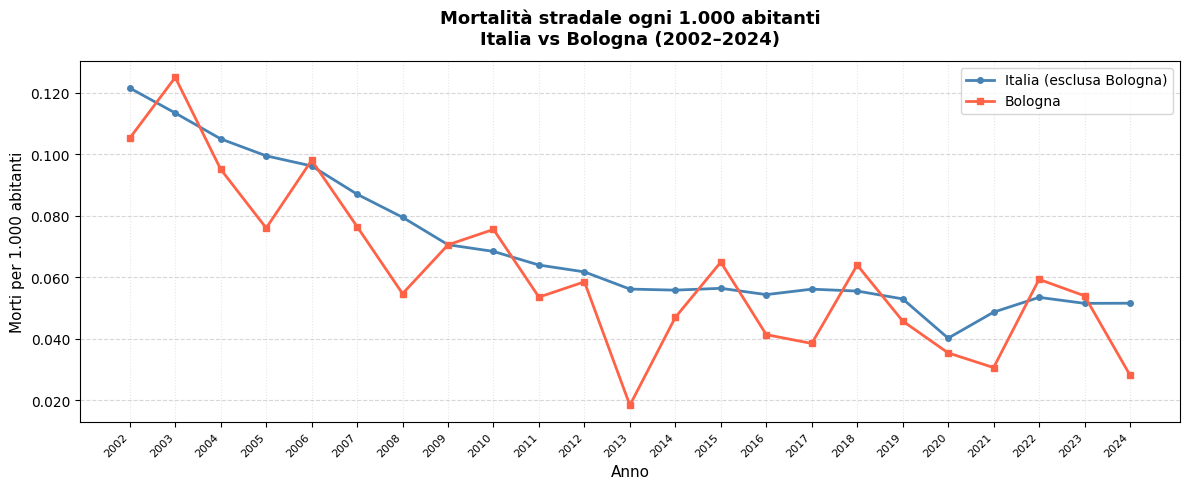


Anno  | Italia (no BO) | Bologna
------+----------------+---------
2002  |   0.1215        | 0.1052
2003  |   0.1133        | 0.1249
2004  |   0.1049        | 0.0951
2005  |   0.0994        | 0.0760
2006  |   0.0961        | 0.0980
2007  |   0.0870        | 0.0764
2008  |   0.0795        | 0.0546
2009  |   0.0705        | 0.0705
2010  |   0.0684        | 0.0755
2011  |   0.0640        | 0.0535
2012  |   0.0617        | 0.0585
2013  |   0.0561        | 0.0184
2014  |   0.0558        | 0.0470
2015  |   0.0564        | 0.0649
2016  |   0.0543        | 0.0413
2017  |   0.0561        | 0.0385
2018  |   0.0555        | 0.0639
2019  |   0.0530        | 0.0458
2020  |   0.0402        | 0.0354
2021  |   0.0486        | 0.0306
2022  |   0.0535        | 0.0593
2023  |   0.0515        | 0.0540
2024  |   0.0515        | 0.0282


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# -------------------------------------------------------
# Dati: join df (incidenti) + df_pop (popolazione)
# -------------------------------------------------------
anni = list(range(2002, 2025))

_key_df  = df['Comune'].str.strip().str.lower()
_key_pop = df_pop['Comune'].str.strip().str.lower()

df_joined = df.copy()
df_joined['_key'] = _key_df
df_pop_tmp2 = df_pop.copy()
df_pop_tmp2['_key'] = _key_pop

df_joined = df_joined.merge(df_pop_tmp2[['_key'] + [str(a) for a in anni]], on='_key')

is_bologna = df_joined['Comune'].str.strip().str.lower() == 'bologna'

# -------------------------------------------------------
# Calcolo tasso aggregato per ogni anno
# (somma morti / somma popolazione * 1000)
# -------------------------------------------------------
def tasso_aggregato(mask, anni):
    tassi = []
    for anno in anni:
        morti = df_joined.loc[mask, f'{anno}_morti'].sum()
        pop   = df_joined.loc[mask, str(anno)].replace(0, np.nan).sum()
        tassi.append(morti / pop * 1000 if pop else np.nan)
    return tassi

tasso_italia   = tasso_aggregato(~is_bologna, anni)
tasso_bologna  = tasso_aggregato(is_bologna,  anni)

# -------------------------------------------------------
# Grafico
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(anni, tasso_italia,  marker='o', linewidth=2, markersize=4,
        color='steelblue', label='Italia (esclusa Bologna)')
ax.plot(anni, tasso_bologna, marker='s', linewidth=2, markersize=5,
        color='tomato',    label='Bologna')

ax.set_title('Mortalità stradale ogni 1.000 abitanti\nItalia vs Bologna (2002–2024)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Anno', fontsize=11)
ax.set_ylabel('Morti per 1.000 abitanti', fontsize=11)
ax.set_xticks(anni)
ax.set_xticklabels(anni, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(axis='x', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

# Riepilogo numerico
print("\nAnno  | Italia (no BO) | Bologna")
print("------+----------------+---------")
for i, anno in enumerate(anni):
    print(f"{anno}  |   {tasso_italia[i]:.4f}        | {tasso_bologna[i]:.4f}")


  ANALISI ANNO 2013
  Comuni nel dataset    : 8,027
  Popolazione totale   : 60,329,522
  Morti totali         : 3,373
  Feriti totali        : 256,777
  Incidenti totali     : 180,728
  Tasso mortalità IT   : 0.0559 x 1.000 ab.
  Tasso mortalità BO   : 0.0184 x 1.000 ab.


/tmp/ipykernel_1015/2490574996.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[f'{ANNO}_morti'].sum() /
/tmp/ipykernel_1015/2490574996.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


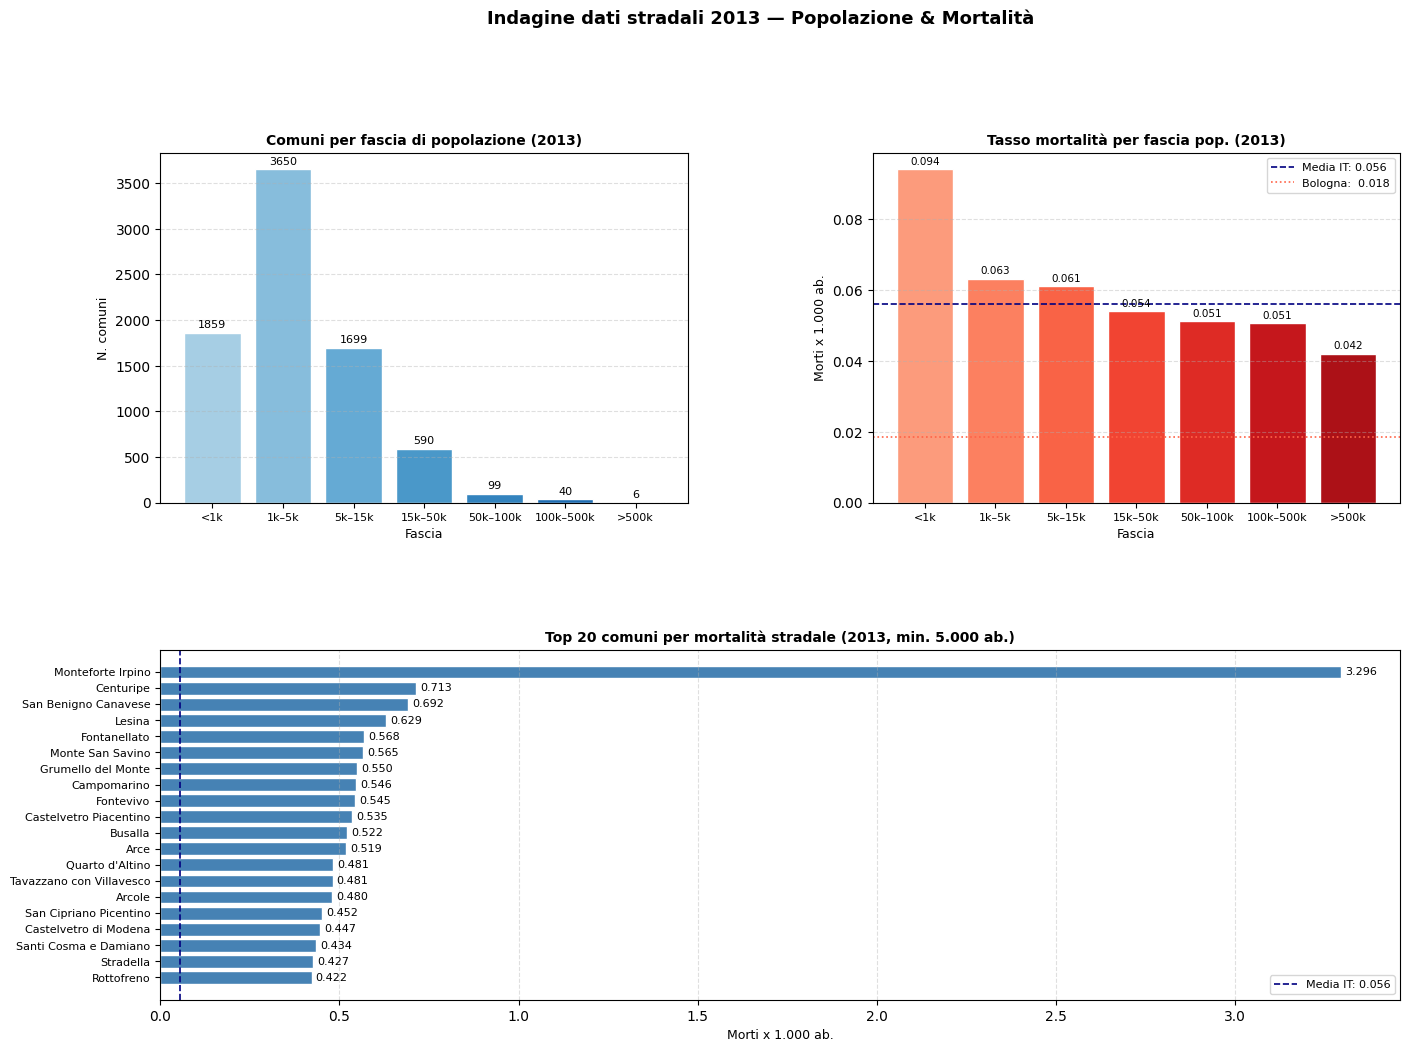

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

ANNO = 2013

# -------------------------------------------------------
# Dati 2013: join df_final (già costruito) con df_pop
# -------------------------------------------------------
# Recupera popolazione 2013 da df_pop
pop_2013 = df_pop[['Comune', str(ANNO)]].copy()
pop_2013.columns = ['Comune', 'pop_2013']
pop_2013['_key'] = pop_2013['Comune'].str.strip().str.lower()

df_2013 = df_final[['Comune', f'{ANNO}_morti', f'{ANNO}_feriti',
                     f'{ANNO}_incidenti', f'{ANNO}_tasso_mortalita',
                     f'{ANNO}_tasso_ferimento']].copy()
df_2013['_key'] = df_2013['Comune'].str.strip().str.lower()
df_2013 = df_2013.merge(pop_2013[['_key','pop_2013']], on='_key').drop(columns='_key')

# -------------------------------------------------------
# KPI aggregati
# -------------------------------------------------------
morti_tot   = df_2013[f'{ANNO}_morti'].sum()
feriti_tot  = df_2013[f'{ANNO}_feriti'].sum()
incid_tot   = df_2013[f'{ANNO}_incidenti'].sum()
pop_tot     = df_2013['pop_2013'].replace(0, np.nan).sum()
tasso_naz   = morti_tot / pop_tot * 1000

pop_bo      = df_2013.loc[df_2013['Comune']=='Bologna', 'pop_2013'].values[0]
morti_bo    = df_2013.loc[df_2013['Comune']=='Bologna', f'{ANNO}_morti'].values[0]
tasso_bo    = morti_bo / pop_bo * 1000 if pop_bo else np.nan

print(f"{'='*55}")
print(f"  ANALISI ANNO {ANNO}")
print(f"{'='*55}")
print(f"  Comuni nel dataset    : {len(df_2013):,}")
print(f"  Popolazione totale   : {int(pop_tot):,}")
print(f"  Morti totali         : {int(morti_tot):,}")
print(f"  Feriti totali        : {int(feriti_tot):,}")
print(f"  Incidenti totali     : {int(incid_tot):,}")
print(f"  Tasso mortalità IT   : {tasso_naz:.4f} x 1.000 ab.")
print(f"  Tasso mortalità BO   : {tasso_bo:.4f} x 1.000 ab.")
print(f"{'='*55}")

# -------------------------------------------------------
# Top 20 comuni per tasso mortalità (min 5.000 ab.)
# -------------------------------------------------------
df_top = (df_2013[df_2013['pop_2013'] >= 5000]
          .sort_values(f'{ANNO}_tasso_mortalita', ascending=False)
          .head(20))

# -------------------------------------------------------
# Distribuzione popolazione 2013
# -------------------------------------------------------
bins = [0, 1_000, 5_000, 15_000, 50_000, 100_000, 500_000, np.inf]
labels = ['<1k', '1k–5k', '5k–15k', '15k–50k', '50k–100k', '100k–500k', '>500k']
df_2013['fascia_pop'] = pd.cut(df_2013['pop_2013'], bins=bins, labels=labels)
pop_dist = df_2013['fascia_pop'].value_counts().reindex(labels)

# -------------------------------------------------------
# Layout 2×2
# -------------------------------------------------------
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# --- 1. Distribuzione comuni per fascia di popolazione ---
ax1 = fig.add_subplot(gs[0, 0])
colors_bar = plt.cm.Blues(np.linspace(0.35, 0.85, len(labels)))
bars = ax1.bar(labels, pop_dist.values, color=colors_bar, edgecolor='white')
ax1.bar_label(bars, fmt='%d', fontsize=8, padding=2)
ax1.set_title(f'Comuni per fascia di popolazione ({ANNO})', fontsize=10, fontweight='bold')
ax1.set_xlabel('Fascia', fontsize=9)
ax1.set_ylabel('N. comuni', fontsize=9)
ax1.tick_params(axis='x', labelsize=8)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- 2. Tasso mortalità per fascia di popolazione ---
ax2 = fig.add_subplot(gs[0, 1])
fascia_tasso = (df_2013.groupby('fascia_pop', observed=True)
                .apply(lambda g: g[f'{ANNO}_morti'].sum() /
                       g['pop_2013'].replace(0,np.nan).sum() * 1000)
                .reindex(labels))
colors_tasso = plt.cm.Reds(np.linspace(0.35, 0.85, len(labels)))
bars2 = ax2.bar(labels, fascia_tasso.values, color=colors_tasso, edgecolor='white')
ax2.bar_label(bars2, fmt='%.3f', fontsize=7.5, padding=2)
ax2.axhline(tasso_naz, color='navy', linestyle='--', linewidth=1.2, label=f'Media IT: {tasso_naz:.3f}')
ax2.axhline(tasso_bo,  color='tomato', linestyle=':',  linewidth=1.2, label=f'Bologna:  {tasso_bo:.3f}')
ax2.legend(fontsize=8)
ax2.set_title(f'Tasso mortalità per fascia pop. ({ANNO})', fontsize=10, fontweight='bold')
ax2.set_xlabel('Fascia', fontsize=9)
ax2.set_ylabel('Morti x 1.000 ab.', fontsize=9)
ax2.tick_params(axis='x', labelsize=8)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# --- 3. Top 20 comuni per tasso mortalità ---
ax3 = fig.add_subplot(gs[1, :])
colors_top = ['tomato' if c == 'Bologna' else 'steelblue' for c in df_top['Comune']]
bars3 = ax3.barh(df_top['Comune'][::-1],
                 df_top[f'{ANNO}_tasso_mortalita'][::-1],
                 color=colors_top[::-1], edgecolor='white')
ax3.bar_label(bars3, fmt='%.3f', fontsize=8, padding=3)
ax3.axvline(tasso_naz, color='navy', linestyle='--', linewidth=1.2,
            label=f'Media IT: {tasso_naz:.3f}')
ax3.legend(fontsize=8)
ax3.set_title(f'Top 20 comuni per mortalità stradale ({ANNO}, min. 5.000 ab.)',
              fontsize=10, fontweight='bold')
ax3.set_xlabel('Morti x 1.000 ab.', fontsize=9)
ax3.tick_params(axis='y', labelsize=8)
ax3.grid(axis='x', linestyle='--', alpha=0.4)

fig.suptitle(f'Indagine dati stradali {ANNO} — Popolazione & Mortalità',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Anno | Pop       | Morti | Feriti | Incidenti | Tasso x1000 | Gravità (morti/incid)
------------------------------------------------------------------------------------------
2002  | 370,797.0 |    39 |   3837 |      2895 |     0.1052 |  0.0135
2003  | 368,226.0 |    46 |   3703 |      2810 |     0.1249 |  0.0164 ◄ ANOMALIA?
2004  | 368,211.0 |    35 |   3672 |      2849 |     0.0951 |  0.0123
2005  | 368,544.0 |    28 |   3554 |      2755 |     0.0760 |  0.0102
2006  | 367,427.0 |    36 |   3602 |      2740 |     0.0980 |  0.0131
2007  | 366,325.0 |    28 |   3630 |      2743 |     0.0764 |  0.0102
2008  | 365,983.0 |    20 |   3241 |      2508 |     0.0546 |  0.0080
2009  | 368,624.0 |    26 |   2976 |      2288 |     0.0705 |  0.0114
2010  | 370,755.0 |    28 |   2844 |      2164 |     0.0755 |  0.0129
2011  | 373,618.0 |    20 |   2980 |      2262 |     0.0535 |  0.0088
2012  | 376,024.0 |    22 |   2470 |      1944 |     0.0585 |  0.0113
2013  | 379,984.0 |     7 |   2604 |      1

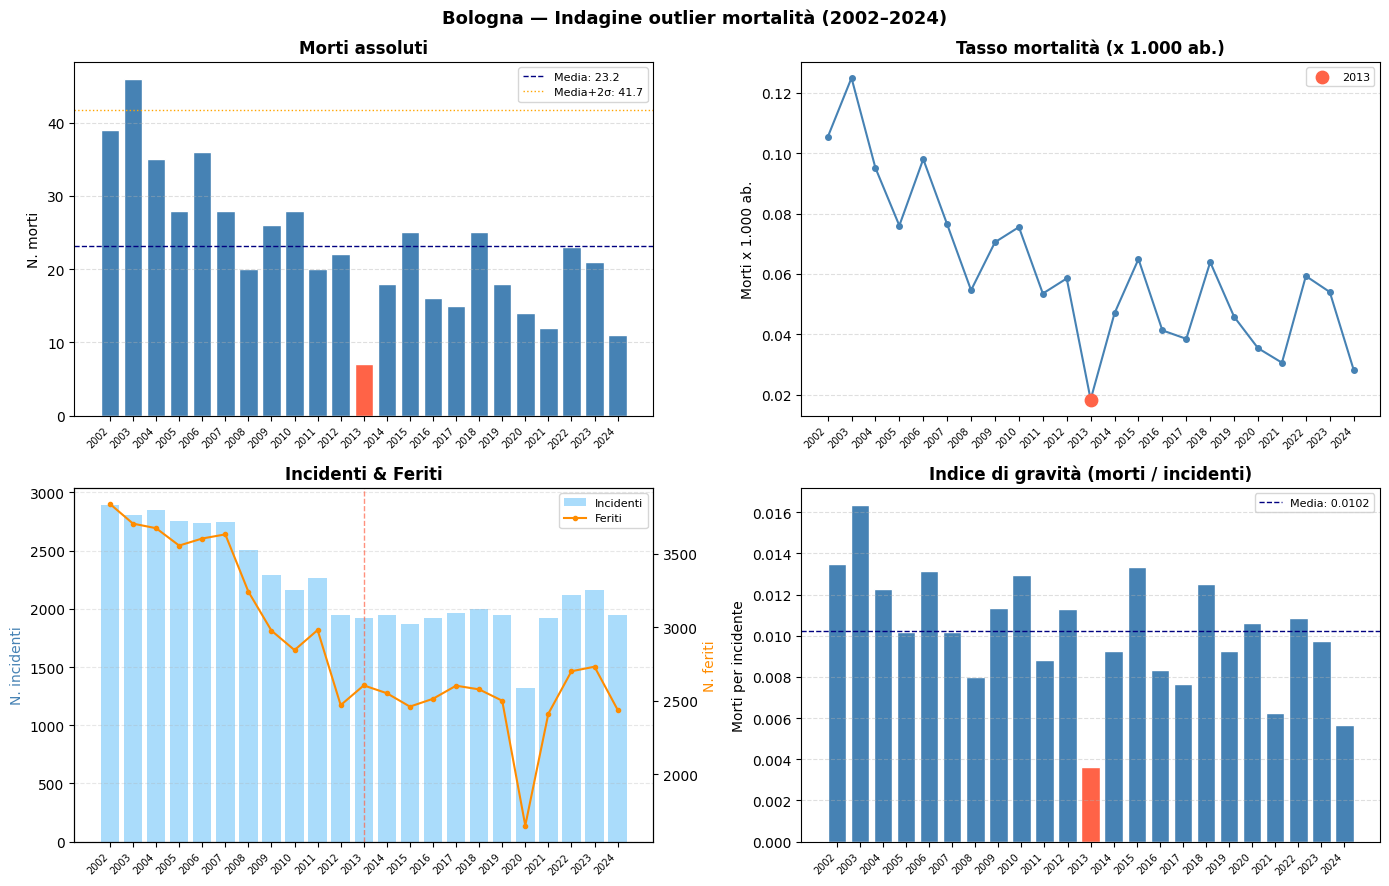


--- ZOOM 2011–2015 ---
Anno   |  Morti | Incidenti |  Feriti |    Tasso |  Gravità
------------------------------------------------------------
  2011 |     20 |      2262 |    2980 |   0.0535 |   0.0088
  2012 |     22 |      1944 |    2470 |   0.0585 |   0.0113
  2013 |      7 |      1924 |    2604 |   0.0184 |   0.0036
  2014 |     18 |      1944 |    2551 |   0.0470 |   0.0093
  2015 |     25 |      1872 |    2460 |   0.0649 |   0.0134


In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# -------------------------------------------------------
# Focus: Bologna — dati grezzi anno per anno
# -------------------------------------------------------
anni = list(range(2002, 2025))

bo = df_final[df_final['Comune'] == 'Bologna'].iloc[0]
pop_bo_series = {a: df_pop.loc[df_pop['Comune'] == 'Bologna', str(a)].values[0]
                 for a in anni}

morti_bo    = [bo[f'{a}_morti']           for a in anni]
feriti_bo   = [bo[f'{a}_feriti']          for a in anni]
incidenti_bo= [bo[f'{a}_incidenti']       for a in anni]
pop_bo      = [pop_bo_series[a]           for a in anni]
tasso_bo    = [bo[f'{a}_tasso_mortalita'] for a in anni]

# Rapporto morti/incidenti (indice di gravità)
gravita_bo  = [m/i if i > 0 else np.nan for m, i in zip(morti_bo, incidenti_bo)]

print("Anno | Pop       | Morti | Feriti | Incidenti | Tasso x1000 | Gravità (morti/incid)")
print("-"*90)
for i, a in enumerate(anni):
    flag = " ◄ ANOMALIA?" if morti_bo[i] > np.mean(morti_bo) + 2*np.std(morti_bo) else ""
    print(f"{a}  | {pop_bo[i]:>9,} |  {morti_bo[i]:>4} |  {feriti_bo[i]:>5} |     {incidenti_bo[i]:>5} |     {tasso_bo[i]:.4f} |  {gravita_bo[i]:.4f}{flag}")

# -------------------------------------------------------
# Grafici
# -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Bologna — Indagine outlier mortalità (2002–2024)',
             fontsize=13, fontweight='bold')

colors = ['tomato' if a == 2013 else 'steelblue' for a in anni]

# 1. Morti assoluti
ax = axes[0, 0]
ax.bar(anni, morti_bo, color=colors, edgecolor='white')
ax.axhline(np.mean(morti_bo), color='navy', linestyle='--', linewidth=1,
           label=f'Media: {np.mean(morti_bo):.1f}')
ax.axhline(np.mean(morti_bo) + 2*np.std(morti_bo), color='orange', linestyle=':',
           linewidth=1, label=f'Media+2σ: {np.mean(morti_bo)+2*np.std(morti_bo):.1f}')
ax.set_title('Morti assoluti', fontweight='bold')
ax.set_ylabel('N. morti')
ax.legend(fontsize=8)
ax.set_xticks(anni); ax.set_xticklabels(anni, rotation=45, ha='right', fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 2. Tasso mortalità x 1000
ax = axes[0, 1]
ax.plot(anni, tasso_bo, marker='o', markersize=4, color='steelblue', linewidth=1.5)
ax.scatter([2013], [tasso_bo[anni.index(2013)]], color='tomato', s=80, zorder=5,
           label='2013')
ax.set_title('Tasso mortalità (x 1.000 ab.)', fontweight='bold')
ax.set_ylabel('Morti x 1.000 ab.')
ax.legend(fontsize=8)
ax.set_xticks(anni); ax.set_xticklabels(anni, rotation=45, ha='right', fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 3. Incidenti e feriti (per escludere errori nel denominatore)
ax = axes[1, 0]
ax2_twin = ax.twinx()
ax.bar(anni, incidenti_bo, color='lightskyblue', alpha=0.7, label='Incidenti')
ax2_twin.plot(anni, feriti_bo, color='darkorange', marker='o', markersize=3,
              linewidth=1.5, label='Feriti')
ax.set_title('Incidenti & Feriti', fontweight='bold')
ax.set_ylabel('N. incidenti', color='steelblue')
ax2_twin.set_ylabel('N. feriti', color='darkorange')
ax.set_xticks(anni); ax.set_xticklabels(anni, rotation=45, ha='right', fontsize=7)
ax.axvline(2013, color='tomato', linestyle='--', linewidth=1, alpha=0.7)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Gravità: morti per incidente
ax = axes[1, 1]
ax.bar(anni, gravita_bo, color=colors, edgecolor='white')
ax.axhline(np.nanmean(gravita_bo), color='navy', linestyle='--', linewidth=1,
           label=f'Media: {np.nanmean(gravita_bo):.4f}')
ax.set_title('Indice di gravità (morti / incidenti)', fontweight='bold')
ax.set_ylabel('Morti per incidente')
ax.legend(fontsize=8)
ax.set_xticks(anni); ax.set_xticklabels(anni, rotation=45, ha='right', fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Zoom: 2011-2015 per isolare l'anomalia
# -------------------------------------------------------
anni_zoom = [2011, 2012, 2013, 2014, 2015]
idx_zoom  = [anni.index(a) for a in anni_zoom]

print("\n--- ZOOM 2011–2015 ---")
print(f"{'Anno':6} | {'Morti':>6} | {'Incidenti':>9} | {'Feriti':>7} | {'Tasso':>8} | {'Gravità':>8}")
print("-"*60)
for a in anni_zoom:
    i = anni.index(a)
    print(f"{a:6} | {morti_bo[i]:>6} | {incidenti_bo[i]:>9} | {feriti_bo[i]:>7} | "
          f"{tasso_bo[i]:>8.4f} | {gravita_bo[i]:>8.4f}")